# 图像放大缩小，灰度变换的加减乘除，图像的旋转和平移

In [1]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import cv2

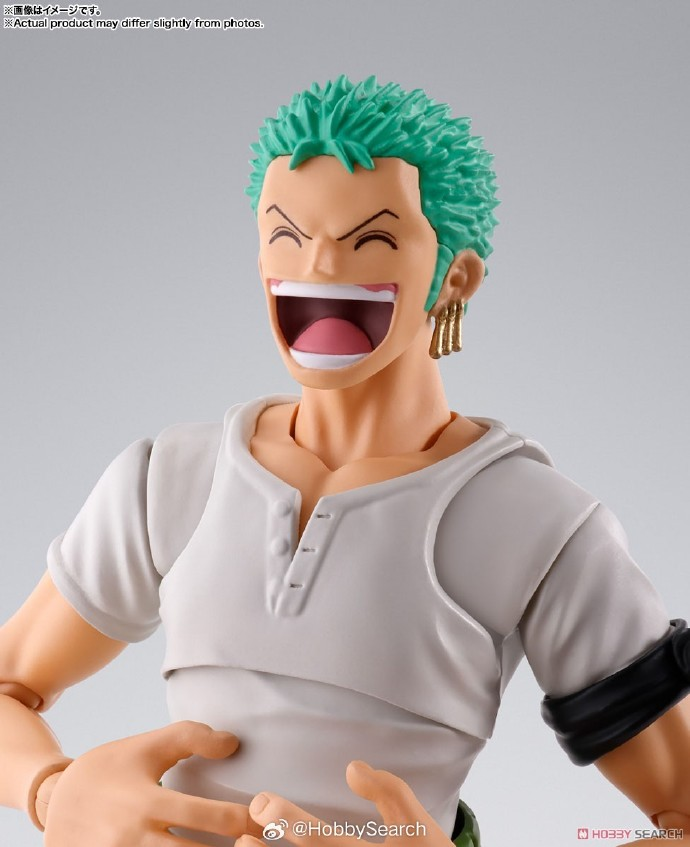

In [5]:
image = Image.open('1.jpg')
image

In [7]:
image.size

(690, 847)

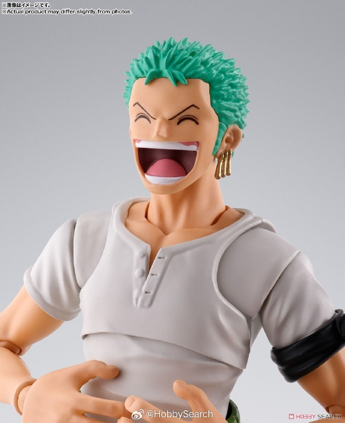

In [13]:
h,w = image.size
scale = 0.5
re_h = int(h*scale)
re_w = int(w*scale)
image2 = image.resize((re_h,re_w))
image2

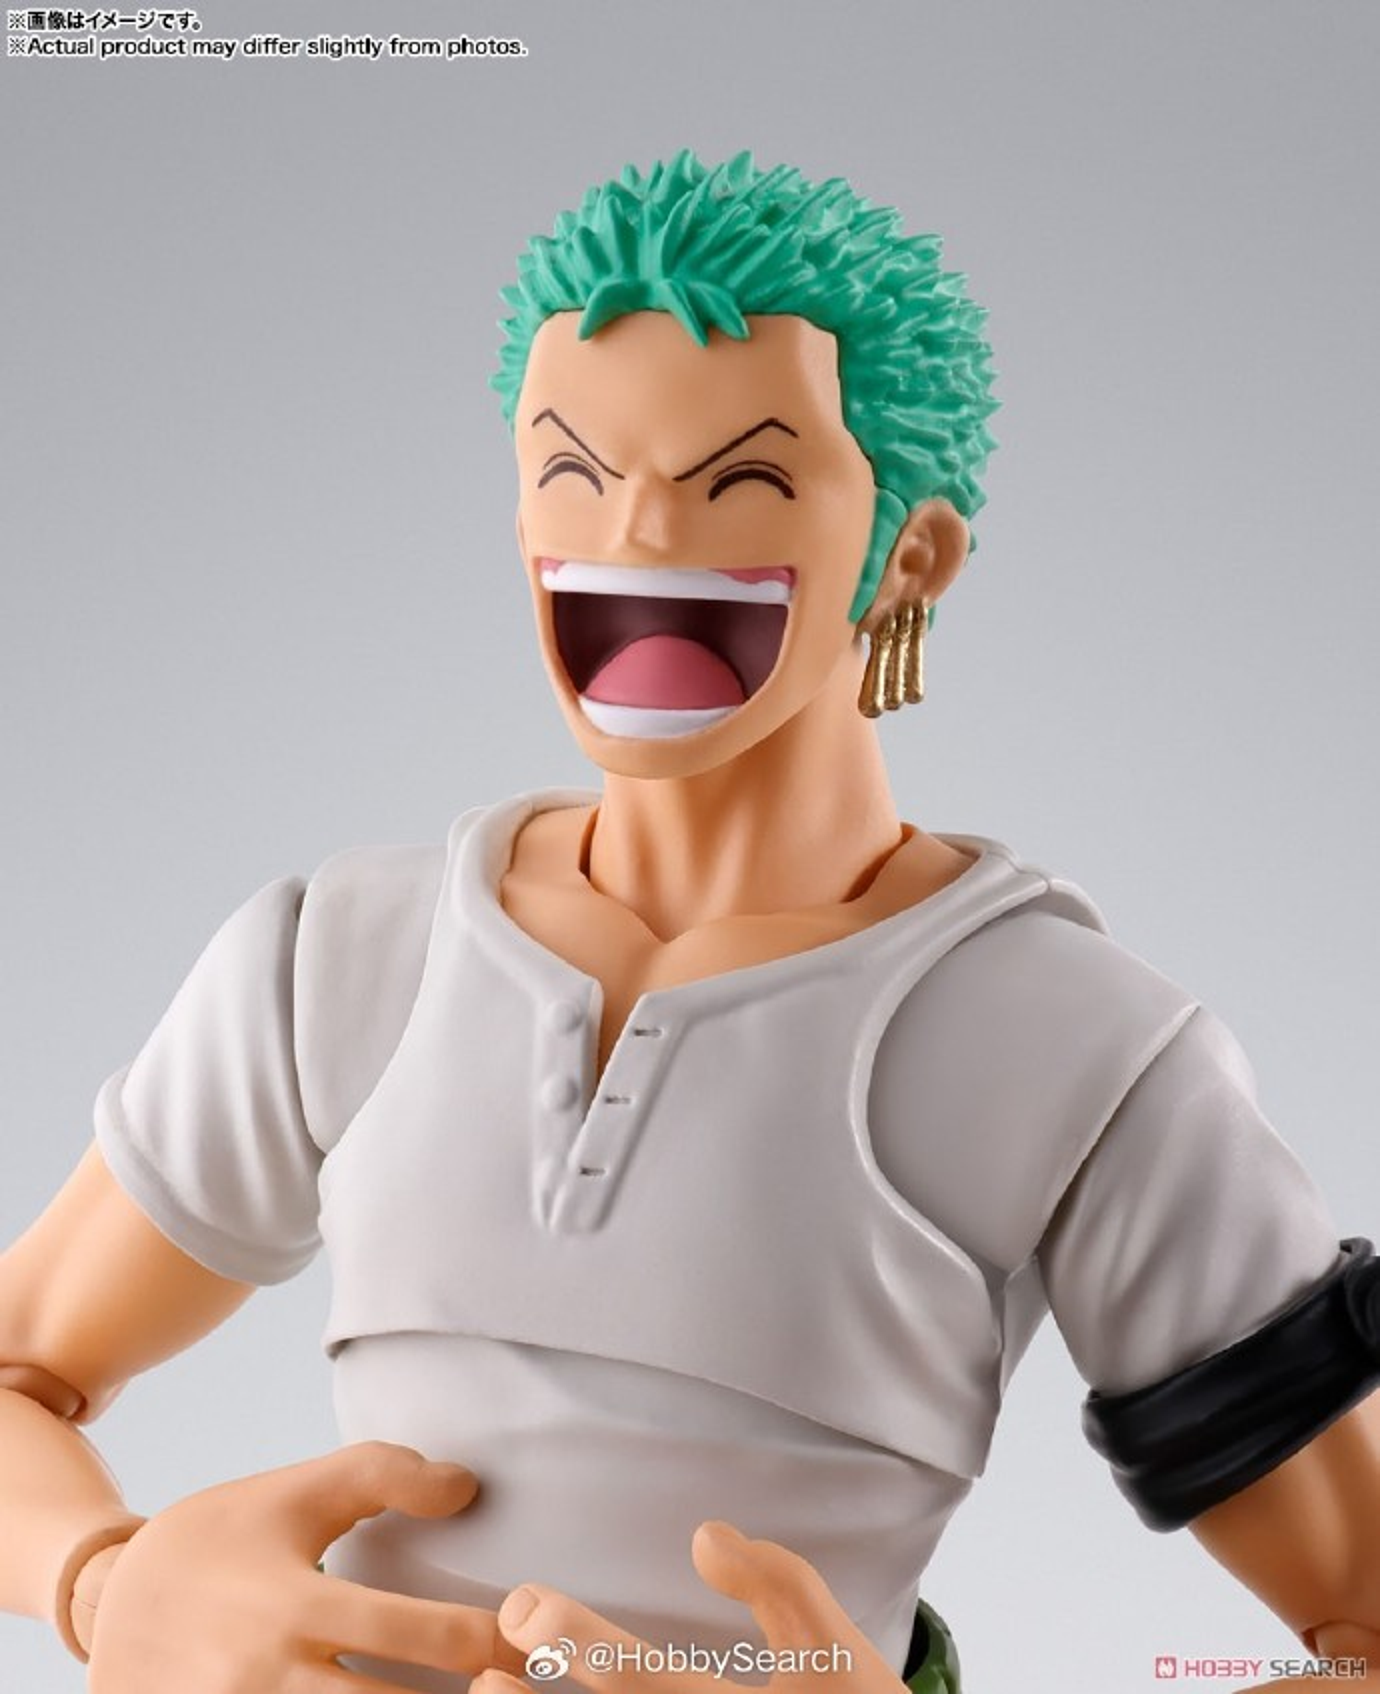

In [14]:
scale2 = 2
re_h2 = int(h*scale2)
re_w2 = int(w*scale2)
image3 = image.resize((re_h2,re_w2))
image3

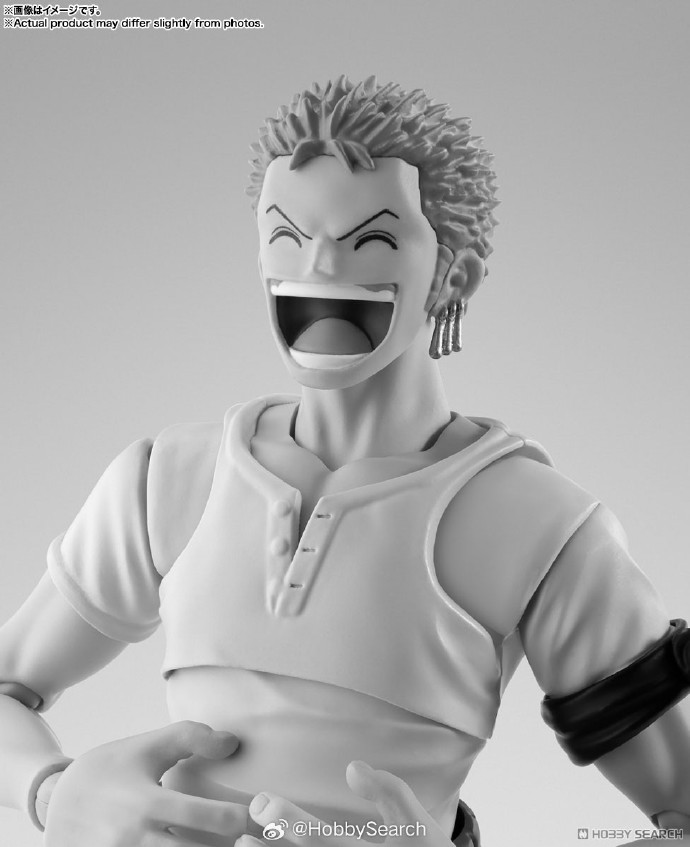

In [15]:
image_gray = image.convert("L")
image_gray

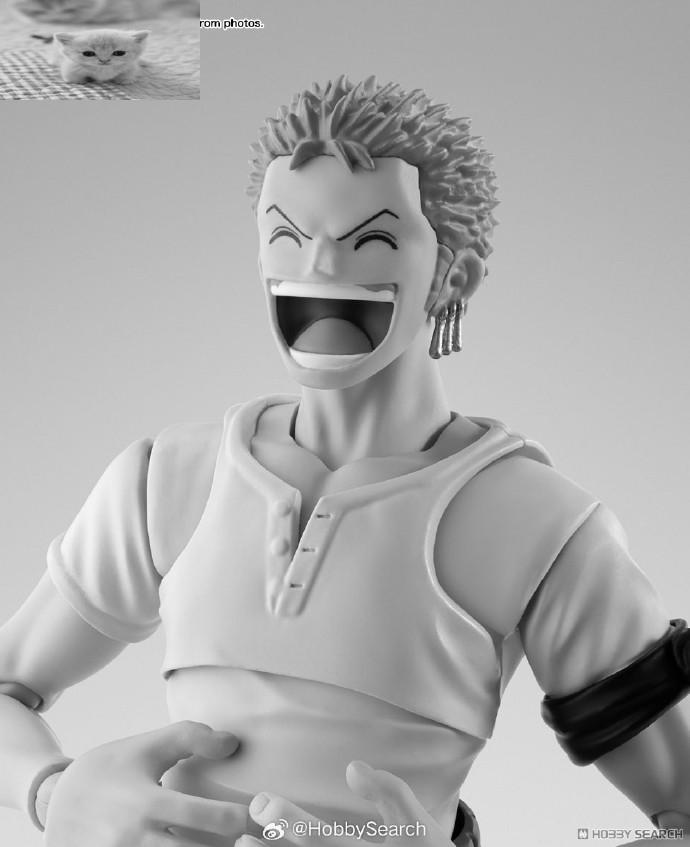

In [74]:
cat = Image.open('cat.jpeg')
window1 = 200
window2 = 100
cat_gray = cat.convert("L").resize((window1,window2))
def concat_image(image1,image2,window):
    image1 = np.array(image1)
    image2 = np.array(image2)
    for width in range(image1.shape[0]):
        for height in range(image1.shape[1]):
            if width < window1 and height < window2:
#                 print(height,width)
                image1[height][width] = image2[height][width]
    return image1

image_gray_cat = Image.fromarray(concat_image(image_gray,cat_gray,window))
image_gray_cat
            

In [67]:
print(cat_gray.size)
cat_gray_array = np.array(cat_gray)
cat_gray_array.shape

(200, 180)


(180, 200)

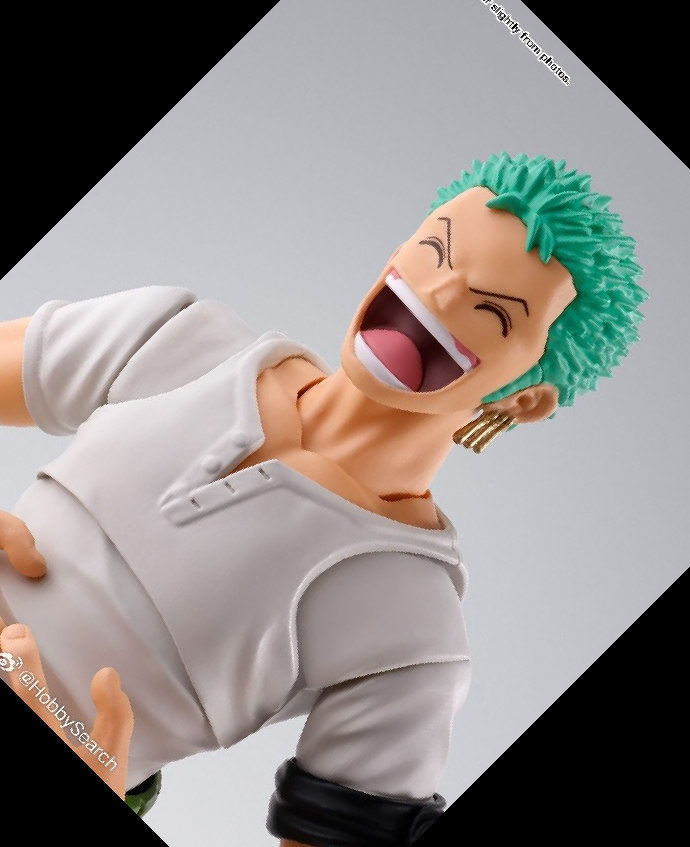

In [17]:
angle = -45
rotate_image = image.rotate(angle)
rotate_image

In [32]:
def translate_image(height,width,x_offset,y_offset,image):
    
    image_temp = np.array(image)
    new_image = [[0 for _ in range(width)] for _ in range(height)]   #构造一个画布
    
    for i in range(height):
        for j in range(width):
            
            if i > y_offset and j > x_offset:
                
                new_image[i][j] = image_temp[i-y_offset][j-x_offset]
    return new_image
    

In [47]:
w,h = image.size
x_offset = 100
y_offset = 100
flit_image = translate_image(h,w,x_offset,y_offset,image_gray)
filt_image = Image.fromarray(np.array(flit_image))

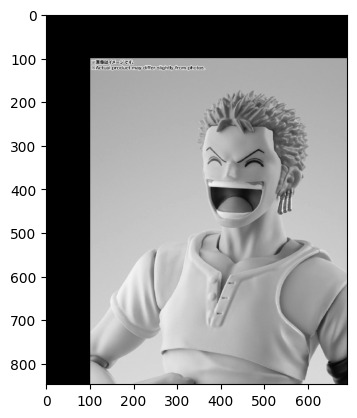

In [48]:
plt.imshow(flit_image,cmap='gray')
plt.show()